In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Load the Data

In [4]:
df = pd.read_csv("/content/drive/MyDrive/Python Programs/samplesuperstore - samplesuperstore.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


## 2. Initial Data Understanding

Inspect structure, data types, and summary statistics before any cleaning.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,10194.0,NaN,NaN,NaN,5097.5,2942.898656,1.0,2549.25,5097.5,7645.75,10194.0
Order ID,10194,5111,US-2026-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,10194,1242,9/5/2025,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Date,10194,1338,12/16/2024,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,10194,4,Standard Class,6120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,10194,804,WB-21850,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,10194,800,William Brown,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,10194,3,Consumer,5281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country/Region,10194,2,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,10194,542,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape of dataset: (10194, 21)

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


## 3. Data Cleaning

### 3.1 Check for missing values and duplicate rows

In [8]:
print("Missing values per column:\n")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values per column:

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

Number of duplicate rows: 0


### 3.2 Convert `Order Date` and `Ship Date` to datetime objects

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df[['Order Date', 'Ship Date']].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


### 3.3 Clean text formatting across categorical attributes

Standardize `Category`, `Sub-Category`, and `Segment` by stripping extra whitespace
and applying consistent title-case formatting, so values like `" office supplies "`
and `"Office Supplies"` are treated the same.

In [10]:
categorical_cols = ['Category', 'Sub-Category', 'Segment']

print("Unique values BEFORE cleaning:")
for col in categorical_cols:
    print(f"{col}: {sorted(df[col].unique())}")

Unique values BEFORE cleaning:
Category: ['Furniture', 'Office Supplies', 'Technology']
Sub-Category: ['Accessories', 'Appliances', 'Art', 'Binders', 'Bookcases', 'Chairs', 'Copiers', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels', 'Machines', 'Paper', 'Phones', 'Storage', 'Supplies', 'Tables']
Segment: ['Consumer', 'Corporate', 'Home Office']


In [11]:
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

print("Unique values AFTER cleaning:")
for col in categorical_cols:
    print(f"{col}: {sorted(df[col].unique())}")

Unique values AFTER cleaning:
Category: ['Furniture', 'Office Supplies', 'Technology']
Sub-Category: ['Accessories', 'Appliances', 'Art', 'Binders', 'Bookcases', 'Chairs', 'Copiers', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels', 'Machines', 'Paper', 'Phones', 'Storage', 'Supplies', 'Tables']
Segment: ['Consumer', 'Corporate', 'Home Office']


### 3.4 Feature engineering — Delivery Days

Derive the number of days between order and shipment.

In [12]:
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df[['Order Date', 'Ship Date', 'Delivery Days']].head()

,Order Date,Ship Date,Delivery Days
0,2023-01-03,2023-01-07,4
1,2023-01-04,2023-01-08,4
2,2023-01-04,2023-01-08,4
3,2023-01-04,2023-01-08,4
4,2023-01-05,2023-01-12,7


## 4. Summary Statistics for Numerical Attributes

In [13]:
numerical_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Delivery Days']
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,10194.0,228.225854,619.906839,0.444,17.2200,53.91,209.500000,22638.480
Quantity,10194.0,3.791838,2.228317,1.000,2.0000,3.00,5.000000,14.000
Discount,10194.0,0.155385,0.206249,0.000,0.0000,0.20,0.200000,0.800
Profit,10194.0,28.673417,232.465115,-6599.978,1.7608,8.69,29.297925,8399.976
Delivery Days,10194.0,3.961350,1.742829,0.000,3.0000,4.00,5.000000,11.000


In [14]:
print("Mean, Median, Std Dev for each numerical column:\n")
summary = pd.DataFrame({
    'Mean': df[numerical_cols].mean(),
    'Median': df[numerical_cols].median(),
    'Std Dev': df[numerical_cols].std(),
    'Min': df[numerical_cols].min(),
    'Max': df[numerical_cols].max()
})
summary

Mean, Median, Std Dev for each numerical column:



,Mean,Median,Std Dev,Min,Max
Sales,228.225854,53.91,619.906839,0.444,22638.480
Quantity,3.791838,3.00,2.228317,1.000,14.000
Discount,0.155385,0.20,0.206249,0.000,0.800
Profit,28.673417,8.69,232.465115,-6599.978,8399.976
Delivery Days,3.961350,4.00,1.742829,0.000,11.000


## 5. Exploratory Data Analysis

### 5.1 Total Sales by Category

Category
Technology         839893.2790
Furniture          754747.7613
Office Supplies    731893.3140
Name: Sales, dtype: float64


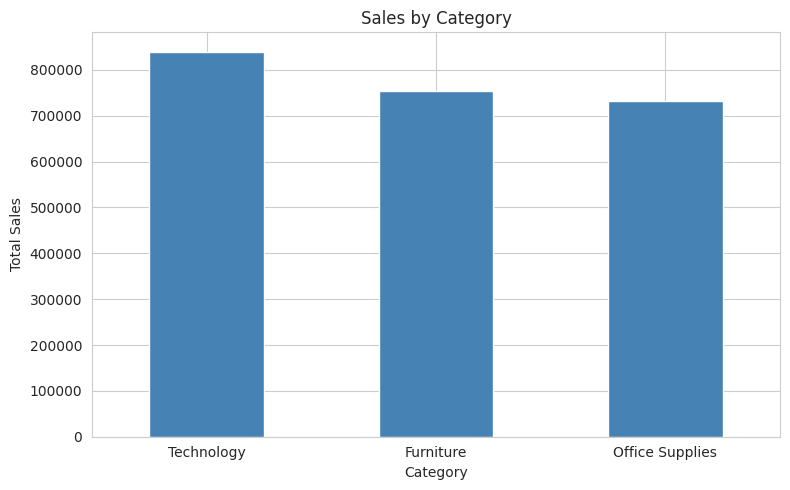

In [15]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

category_sales.plot(kind='bar', figsize=(8, 5), color='steelblue')
plt.title("Sales by Category")
plt.ylabel("Total Sales")
plt.xlabel("Category")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5.2 Sales Distribution

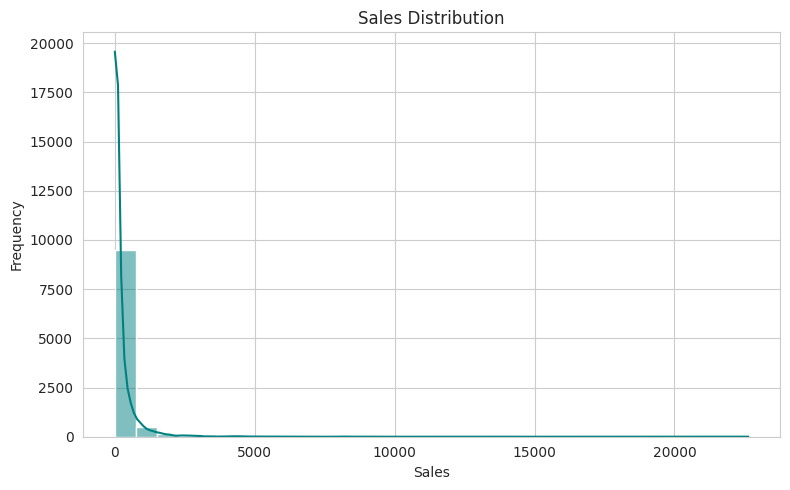

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Sales'], bins=30, kde=True, color='teal')
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 5.3 Total Sales by Sub-Category

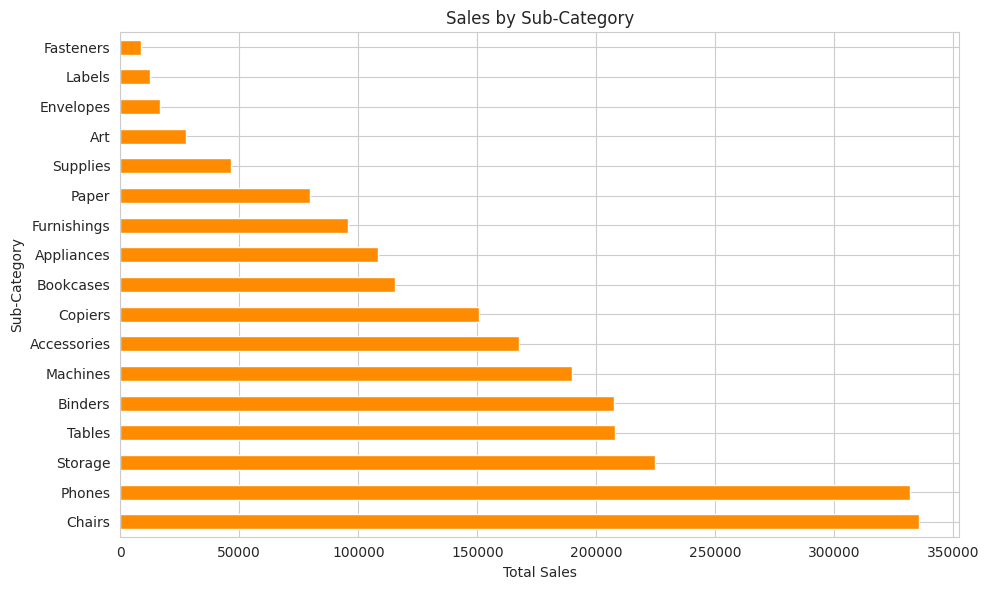

In [17]:
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
subcat_sales.plot(kind='barh', color='darkorange')
plt.title("Sales by Sub-Category")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

### 5.4 Sales by Customer Segment

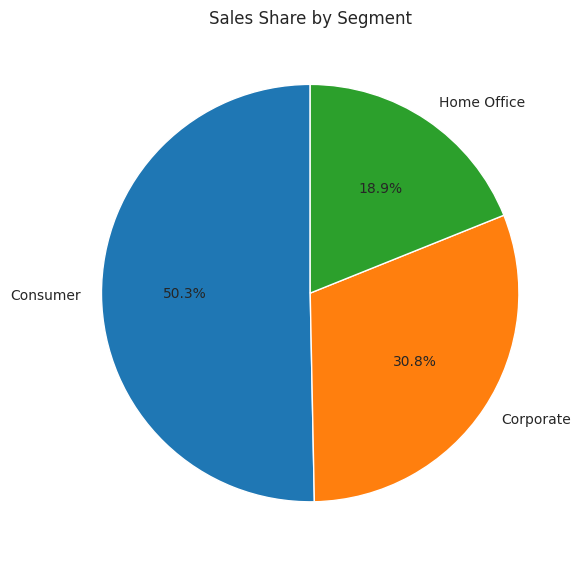

In [18]:
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(6, 6))
plt.pie(segment_sales, labels=segment_sales.index, autopct='%1.1f%%', startangle=90)
plt.title("Sales Share by Segment")
plt.tight_layout()
plt.show()

### 5.5 Correlation Between Numerical Attributes

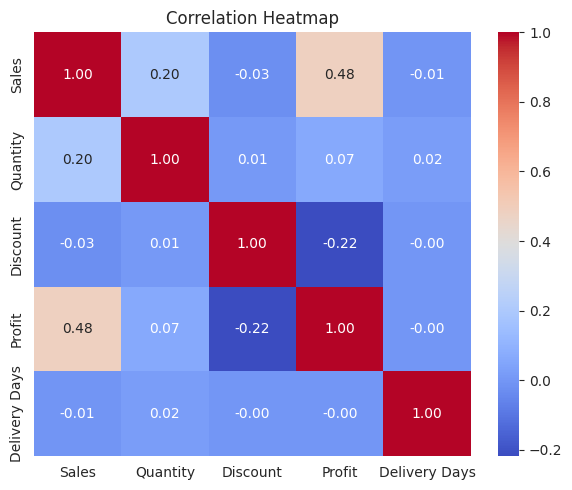

In [19]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()